In [ ]:
import pandas as pd
df = pd.read_csv('/train.csv.zip')
df.head()

,count,hate_speech_count,offensive_language_count,neither_count,class,tweet
0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'@[A-Za-z0-9_]+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    words = text.split()
    cleaned_words = [stemmer.stem(w) for w in words if w not in stop_words]
    return " ".join(cleaned_words)

df['cleaned_tweet'] = df['tweet'].apply(clean_text)

df[['tweet', 'cleaned_tweet', 'class']].head()

,tweet,cleaned_tweet,class
0,!!! RT @mayasolovely: As a woman you shouldn't...,rt woman shouldnt complain clean hous amp man ...,2
1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,rt boy dat coldtyga dwn bad cuffin dat hoe st ...,1
2,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,rt dawg rt ever fuck bitch start cri confus shit,1
3,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,rt look like tranni,1
4,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,rt shit hear might true might faker bitch told ya,1


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

X = df['cleaned_tweet']
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Shape of X_train_tfidf:", X_train_tfidf.shape)

Shape of X_train_tfidf: (19826, 5000)


Accuracy: 87.33%

Classification Report:
              precision    recall  f1-score   support

           0       0.32      0.27      0.29       290
           1       0.92      0.93      0.93      3832
           2       0.81      0.82      0.82       835

    accuracy                           0.87      4957
   macro avg       0.68      0.67      0.68      4957
weighted avg       0.87      0.87      0.87      4957



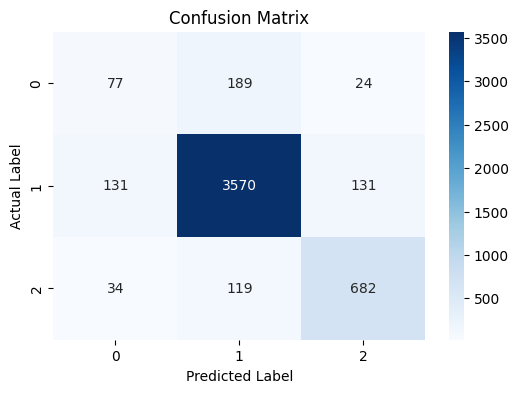

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

In [ ]:
def predict_hate_speech(sample_text):
    cleaned = clean_text(sample_text)
    vectorized = vectorizer.transform([cleaned])
    prediction = model.predict(vectorized)[0]

    labels = {0: "Hate Speech", 1: "Offensive Language", 2: "Normal/Neither"}
    return labels.get(prediction, "Unknown")

print(predict_hate_speech("I really appreciate your hard work!"))

Normal/Neither


In [14]:
import joblib
joblib.dump(model, 'hate_speech_model.pkl')
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')
print("Model and Vectorizer saved successfully!")

Model and Vectorizer saved successfully!
